# **EXPERIMENTO 03 - Regressão Linear Multivariada - Método Analítico**

In [9]:
# Importação do conjunto de dados "Boston House Price Dataset".

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

V = np.loadtxt("boston_housing.csv", delimiter=",", skiprows=1)

In [10]:
# Implantação da função "standardize(V)" que recebe um vetor V e retorna o vetor V padronizado.

# Padronização de cada coluna, analisando todas as variáveis, sendo MEDV ainda variável alvo.

def standardize (V):

    data_padronizado = np.zeros(V.shape)

    media0 = np.mean(V[:,0])
    desv0 = np.std(V[:,0])
    data_padronizado[:,0] = (V[:,0] - media0) / desv0

    media1 = np.mean(V[:,1])
    desv1 = np.std(V[:,1])
    data_padronizado[:,1] = (V[:,1] - media1) / desv1

    media2 = np.mean(V[:,2])
    desv2 = np.std(V[:,2])
    data_padronizado[:,2] = (V[:,2] - media2) / desv2

    media3 = np.mean(V[:,3])
    desv3 = np.std(V[:,3])
    data_padronizado[:,3] = (V[:,3] - media3) / desv3

    return (data_padronizado)

In [11]:
# Valores padronizados e incremento do termo de bias "coluna de 1s".

data_padronizado = standardize(V)

X_true = data_padronizado[:,1]
y_true = data_padronizado[:,3]
w_true = data_padronizado[:,0]
z_true = data_padronizado[:,2]
c1 = np.ones(X_true.shape[0])

X_bias = np.c_[c1, X_true]

df_pandas = pd.DataFrame (data_padronizado, columns = ['X', 'Y', 'W', 'Z'])

X_p = df_pandas['X']
y_p = df_pandas['Y']
w_p = df_pandas['W']
z_p = df_pandas['Z']


In [12]:
# Treinamento do método de Regressão Linear Multivariada usando o método "Analítico".

def regressao_linear(X, y):

    b = (np.linalg.inv( (X.T) @ X)) @ ((X.T) @ y)

    return (b)

In [13]:
# Coeficientes finais.

b = regressao_linear(X_bias, y_true)
print ("b:", np.round(b, 2))

b: [-0.   -0.76]


In [14]:
# Resumo da análise da regressão, utilizando a biblioteca statsmodels (com o método Ordinary Least Squares).

modelo = smf.ols ('Y ~ X', data = df_pandas)
modelo = modelo.fit()
modelo.summary()

print (modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     291.7
Date:                Fri, 24 Oct 2025   Prob (F-statistic):           1.37e-51
Time:                        12:53:22   Log-Likelihood:                -579.11
No. Observations:                 489   AIC:                             1162.
Df Residuals:                     487   BIC:                             1171.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.151e-17      0.036   1.72e-15      1.0

In [15]:
# Predições, Predições convertidas de volta à unidade original (Revertidas à escala original), MSE e R² obtidos com o modelo final.

def predict_multivariate(X, b):

    y_predict = X @ b

    return (y_predict)

def predict_univariate_esc_original(y_predict):

    y_predict_orig = y_predict * np.std(V[:,3]) + np.mean(V[:,3])

    return y_predict_orig

def MSE (y_true, y_predict):
    mse = np.mean ((y_true - y_predict)**2)

    return mse

def R2 (y_true, y_predict):
    r2 = 1 - np.sum((y_true-y_predict)**2) / np.sum((y_true-(np.mean(y_true)))**2)

    return r2

In [16]:
# Predições.

y_predict = predict_multivariate(X_bias, b)
print ("Predições:", f"\n", np.round(y_predict, 2))

Predições: 
 [ 0.86  0.41  0.96  1.08  0.82  0.83  0.05 -0.67 -1.83 -0.45 -0.81 -0.04
 -0.3   0.5   0.29  0.48  0.68 -0.19  0.13  0.18 -0.87 -0.1  -0.62 -0.75
 -0.36 -0.38 -0.2  -0.47  0.02  0.1  -1.04 -0.01 -1.59 -0.58 -0.8   0.35
  0.16  0.45  0.3   0.93  1.18  0.87  0.77  0.59  0.36  0.29 -0.13 -0.63
 -1.92 -0.35 -0.05  0.38  0.82  0.48 -0.2   0.87  0.77  0.97  0.65  0.4
 -0.02 -0.16  0.67  0.37  0.53  0.89  0.29  0.52 -0.02  0.45  0.67  0.33
  0.8   0.58  0.66  0.43  0.1   0.29  0.06  0.41  0.82  0.61  0.67  0.58
  0.36  0.69  0.01  0.48  0.8   0.78  0.44  0.51  0.51  0.72  0.25  0.68
  0.17  0.94  1.01  0.73  0.38  0.57  0.25 -0.05  0.07 -0.38 -0.62 -0.12
  0.07 -0.28 -0.01  0.3  -0.35 -0.45  0.27 -0.3   0.1   0.28 -0.26 -0.07
 -0.15 -0.14 -0.54 -1.34 -0.5  -0.2  -1.54 -0.46 -0.26 -0.58  0.04  0.07
  0.2  -0.22 -0.47 -0.43 -0.43 -0.18 -0.9  -0.59 -1.21 -2.31 -1.49 -1.45
 -1.76 -1.6  -0.4  -1.78 -1.65 -0.92 -0.12 -0.04  0.09 -0.31 -0.23 -0.22
 -0.34  0.9   0.7   0.6   0.8   0.14  0

In [17]:
# Predições - Valores. -- Predições convertidas de volta à unidade original (Revertidas à escala original):

y_predict_orig = predict_univariate_esc_original (y_predict)
print ("Predições com valores convertidos à unidade original:", f"\n", np.round(y_predict_orig, 2),f"\n")

Predições com valores convertidos à unidade original: 
 [595698.43 521820.79 612569.53 631926.89 589482.77 591613.85 463393.52
 344052.72 152610.18 380458.77 320965.95 448475.92 405143.84 537448.75
 501930.66 533719.35 567283.96 423613.25 476535.22 483816.43 310843.3
 438530.85 351689.11 331088.61 394666.01 390936.61 421126.99 377262.14
 456822.67 471385.09 282784.   452560.5  192035.26 358259.96 322919.45
 512230.91 481507.75 528391.64 504239.33 607419.4  648975.58 598184.7
 580958.42 552011.17 514539.58 502818.61 432847.96 350268.38 136982.21
 396441.91 445279.29 516670.67 590370.72 534429.72 421304.58 598717.47
 581668.78 613990.25 562311.42 520400.07 450607.01 427697.84 564620.1
 515427.53 541178.15 601203.74 502285.84 540290.2  451672.55 528036.46
 564797.69 508679.1  586108.55 550235.27 563732.15 525372.6  471562.68
 501753.07 464991.84 522531.15 590193.13 555918.16 564797.69 550768.04
 513296.45 568171.91 455757.13 534252.13 586463.73 582911.92 527681.28
 538514.3  539224.66 573

In [20]:
# MSE

mse = MSE (y_true, y_predict)
print ("MSE:", np.round(mse, 2))

MSE: 0.42


In [21]:
# R²

r2 = R2 (y_true, y_predict)
print ("R2:", np.round(r2, 2))

R2: 0.58


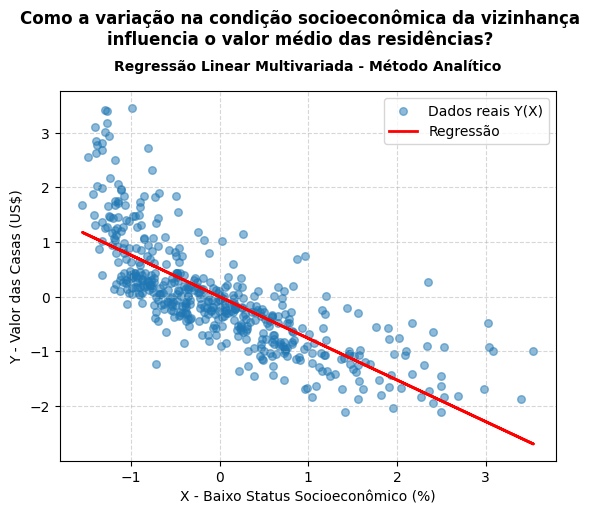

In [28]:
# Visualização gráfica da Regressão Linear Multivariada pelo método Analítico.

plt.scatter(X_true, y_true, label = "Dados reais Y(X)", s=30, alpha=0.5)
plt.plot(X_true, y_predict, color='red', label = "Regressão", linewidth=2)
plt.suptitle("Como a variação na condição socioeconômica da vizinhança\ninfluencia o valor médio das residências?", fontsize=12, fontweight='bold', y=1.05)
plt.title("Regressão Linear Multivariada - Método Analítico", fontsize=10, fontweight='bold', pad =15)
plt.xlabel("X - Baixo Status Socioeconômico (%)", fontsize=10)
plt.ylabel("Y - Valor das Casas (US$)", fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()